In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import torch
import torch.nn as nn
from sklearn.model_selection import train_test_split
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import StandardScaler

In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda')

In [6]:
df = pd.read_csv("../accident.csv") #Dataset URL -> https://www.kaggle.com/datasets/shubhambathwal/flight-price-prediction

In [7]:
df.shape

(307973, 21)

In [8]:
labels = df["Accident_Severity"]
df = df.drop(columns=["Accident Date","Accident_Index","Time","Accident_Severity","Number_of_Casualties"],axis=1)


In [9]:
df = df.drop("Carriageway_Hazards", axis = 1)
df.head()

,Day_of_Week,Junction_Control,Junction_Detail,Latitude,Light_Conditions,Local_Authority_(District),Longitude,Number_of_Vehicles,Police_Force,Road_Surface_Conditions,Road_Type,Speed_limit,Urban_or_Rural_Area,Weather_Conditions,Vehicle_Type
0,Thursday,Give way or uncontrolled,T or staggered junction,51.512273,Daylight,Kensington and Chelsea,-0.201349,2,Metropolitan Police,Dry,One way street,30,Urban,Fine no high winds,Car
1,Monday,Give way or uncontrolled,Crossroads,51.514399,Daylight,Kensington and Chelsea,-0.199248,2,Metropolitan Police,Wet or damp,Single carriageway,30,Urban,Fine no high winds,Taxi/Private hire car
2,Sunday,Give way or uncontrolled,T or staggered junction,51.486668,Daylight,Kensington and Chelsea,-0.179599,2,Metropolitan Police,Dry,Single carriageway,30,Urban,Fine no high winds,Taxi/Private hire car
3,Monday,Auto traffic signal,T or staggered junction,51.507804,Daylight,Kensington and Chelsea,-0.203110,2,Metropolitan Police,Frost or ice,Single carriageway,30,Urban,Other,Motorcycle over 500cc
4,Tuesday,Auto traffic signal,Crossroads,51.482076,Darkness - lights lit,Kensington and Chelsea,-0.173445,2,Metropolitan Police,Dry,Single carriageway,30,Urban,Fine no high winds,Car


In [10]:
df["Urban_or_Rural_Area"].value_counts()

Urban_or_Rural_Area
Urban    198532
Rural    109441
Name: count, dtype: int64

In [11]:
df.head()

,Day_of_Week,Junction_Control,Junction_Detail,Latitude,Light_Conditions,Local_Authority_(District),Longitude,Number_of_Vehicles,Police_Force,Road_Surface_Conditions,Road_Type,Speed_limit,Urban_or_Rural_Area,Weather_Conditions,Vehicle_Type
0,Thursday,Give way or uncontrolled,T or staggered junction,51.512273,Daylight,Kensington and Chelsea,-0.201349,2,Metropolitan Police,Dry,One way street,30,Urban,Fine no high winds,Car
1,Monday,Give way or uncontrolled,Crossroads,51.514399,Daylight,Kensington and Chelsea,-0.199248,2,Metropolitan Police,Wet or damp,Single carriageway,30,Urban,Fine no high winds,Taxi/Private hire car
2,Sunday,Give way or uncontrolled,T or staggered junction,51.486668,Daylight,Kensington and Chelsea,-0.179599,2,Metropolitan Police,Dry,Single carriageway,30,Urban,Fine no high winds,Taxi/Private hire car
3,Monday,Auto traffic signal,T or staggered junction,51.507804,Daylight,Kensington and Chelsea,-0.203110,2,Metropolitan Police,Frost or ice,Single carriageway,30,Urban,Other,Motorcycle over 500cc
4,Tuesday,Auto traffic signal,Crossroads,51.482076,Darkness - lights lit,Kensington and Chelsea,-0.173445,2,Metropolitan Police,Dry,Single carriageway,30,Urban,Fine no high winds,Car


In [12]:
# data.head()

In [13]:
x = {"Urban":1, "Rural":0}
# df["Urban_or_Rural_Area"] = df["Urban_or_Rural_Area"].map(x)
data = pd.get_dummies(df, columns=["Day_of_Week","Junction_Control","Junction_Detail","Light_Conditions","Local_Authority_(District)", "Police_Force","Road_Surface_Conditions","Road_Type","Weather_Conditions",  "Vehicle_Type" ,"Urban_or_Rural_Area" ] ,drop_first=True, dtype=int)

In [14]:
scaler = StandardScaler()
scal_cols = ["Latitude","Longitude","Speed_limit"]
data[scal_cols] = scaler.fit_transform(data[scal_cols])

In [15]:
data = data.values

In [16]:
for i in range(len(labels)):
    if labels[i] == "Fetal"  :
        labels[i] = "Fatal"
    

In [17]:
labels.value_counts()

Accident_Severity
Slight     263280
Serious     40740
Fatal        3953
Name: count, dtype: int64

In [18]:
labels = labels.map({"Slight":0, "Serious":1, "Fatal":2})

In [19]:
labels.value_counts()

Accident_Severity
0    263280
1     40740
2      3953
Name: count, dtype: int64

In [20]:
X_train, X_test, Y_train, Y_test = train_test_split(data, labels ,test_size=0.2, random_state=42)
Y_train.dtype

dtype('int64')

In [55]:
Y_train.shape, Y_test

(torch.Size([246378]), tensor([0, 0, 2,  ..., 0, 0, 0], device='cuda:0'))

In [22]:
X_train= torch.tensor(X_train, dtype=torch.float).to(device)
X_test= torch.tensor(X_test, dtype=torch.float).to(device)
Y_train = torch.tensor(Y_train.to_numpy(), dtype=torch.long).to(device)
Y_test = torch.tensor(Y_test.to_numpy(), dtype=torch.long).to(device)


In [27]:
class AccidentModel(nn.Module):
    def __init__(self, input_size):
        super().__init__()
        self.input_size = input_size
        self.layers = nn.Sequential(
            nn.Linear(input_size, 256),
            nn.Dropout(0.1),
            nn.ReLU(),
            nn.Linear(256,150),
            nn.Dropout(0.1),
            nn.ReLU(),
            nn.Linear(150, 30),
            nn.Dropout(0.1),
            nn.ReLU(),
            nn.Linear(30, 3)
        )

    def forward(self, x):
        return self.layers(x)

In [28]:
torch.manual_seed(42)
input_size = len(labels)
model = AccidentModel(input_size=529).to(device)
loss_func = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params=model.parameters(), lr=1e-3, weight_decay=1e-5)

In [29]:
train_dataset = TensorDataset(X_train, Y_train)
test_dataset = TensorDataset(X_test, Y_test)

train_loader =  DataLoader(train_dataset,batch_size=256,  shuffle=True)
test_loader = DataLoader(test_dataset,batch_size=256,  shuffle=False)

In [42]:
%%time
epochs = 10
training_loss = []
testing_loss = []
epoch_c = []
model.load_state_dict(torch.load("accident.pth"))
for epoch in range(epochs):
    model.train()
    train_loss = 0
    
    for X_batch, Y_batch in train_loader:
        X_batch, Y_batch = X_batch.to(device), Y_batch.to(device)
        Y_logits = model(X_batch)
        # print(Y_logits.shape)
        loss = loss_func(Y_logits, Y_batch)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        # torch.save(model.state_dict(), "accident.pth")
        train_loss += loss.item()
    training_loss.append(train_loss / len(train_loader))
        
    test_loss = 0   
    model.eval()
    with torch.inference_mode():
        for X_batch, Y_batch in test_loader:
            X_batch, Y_batch = X_batch.to(device), Y_batch.to(device)
            Y_test_logits = model(X_batch)
            t_loss = loss_func(Y_test_logits, Y_batch)
            test_loss += t_loss.item()
    
    testing_loss.append(test_loss / len(test_loader))
    epoch_c.append(epoch)
        
    # if epoch%10 == 0:
    print(f"Epoch {epoch} | Train Loss : {train_loss/ len(train_loader)} | Test Loss : {test_loss/ len(train_loader)}") 
    torch.save(model.state_dict(), "accident.pth")

Epoch 0 | Train Loss : 0.2572775629357757 | Test Loss : 0.19050495618971708
Epoch 1 | Train Loss : 0.2582067188846483 | Test Loss : 0.18500736782855334
Epoch 2 | Train Loss : 0.25820867013213294 | Test Loss : 0.19106168817508257
Epoch 3 | Train Loss : 0.25912354940689736 | Test Loss : 0.18719835324079448
Epoch 4 | Train Loss : 0.2569885926392715 | Test Loss : 0.19359507605913148
Epoch 5 | Train Loss : 0.2581747310121978 | Test Loss : 0.18966993677158098
Epoch 6 | Train Loss : 0.257704835814479 | Test Loss : 0.19226983068888062
Epoch 7 | Train Loss : 0.2582810330025751 | Test Loss : 0.1871233029467047
Epoch 8 | Train Loss : 0.2577146195486451 | Test Loss : 0.18768463392866735
Epoch 9 | Train Loss : 0.25733955391718466 | Test Loss : 0.19009614309541656
CPU times: total: 1min 24s
Wall time: 1min 27s


[]

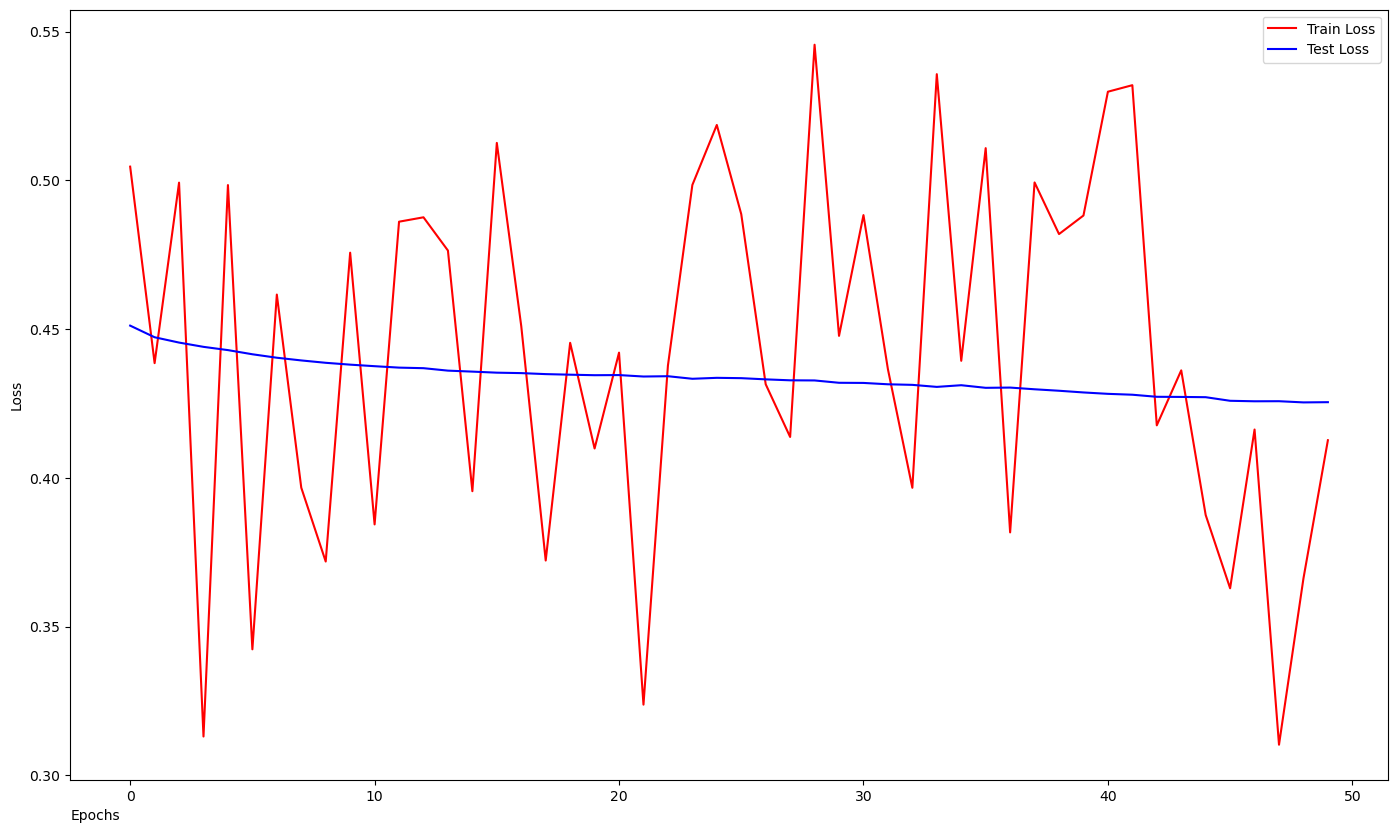

In [154]:
plt.figure(figsize=(17.0,10.0))
plt.xlabel("Epochs",loc='left')
plt.ylabel("Loss")
plt.plot(epoch_c, training_loss, c="red",label="Train Loss")
plt.plot(epoch_c, testing_loss, c="blue",label = "Test Loss")
plt.legend()
plt.plot()

[]

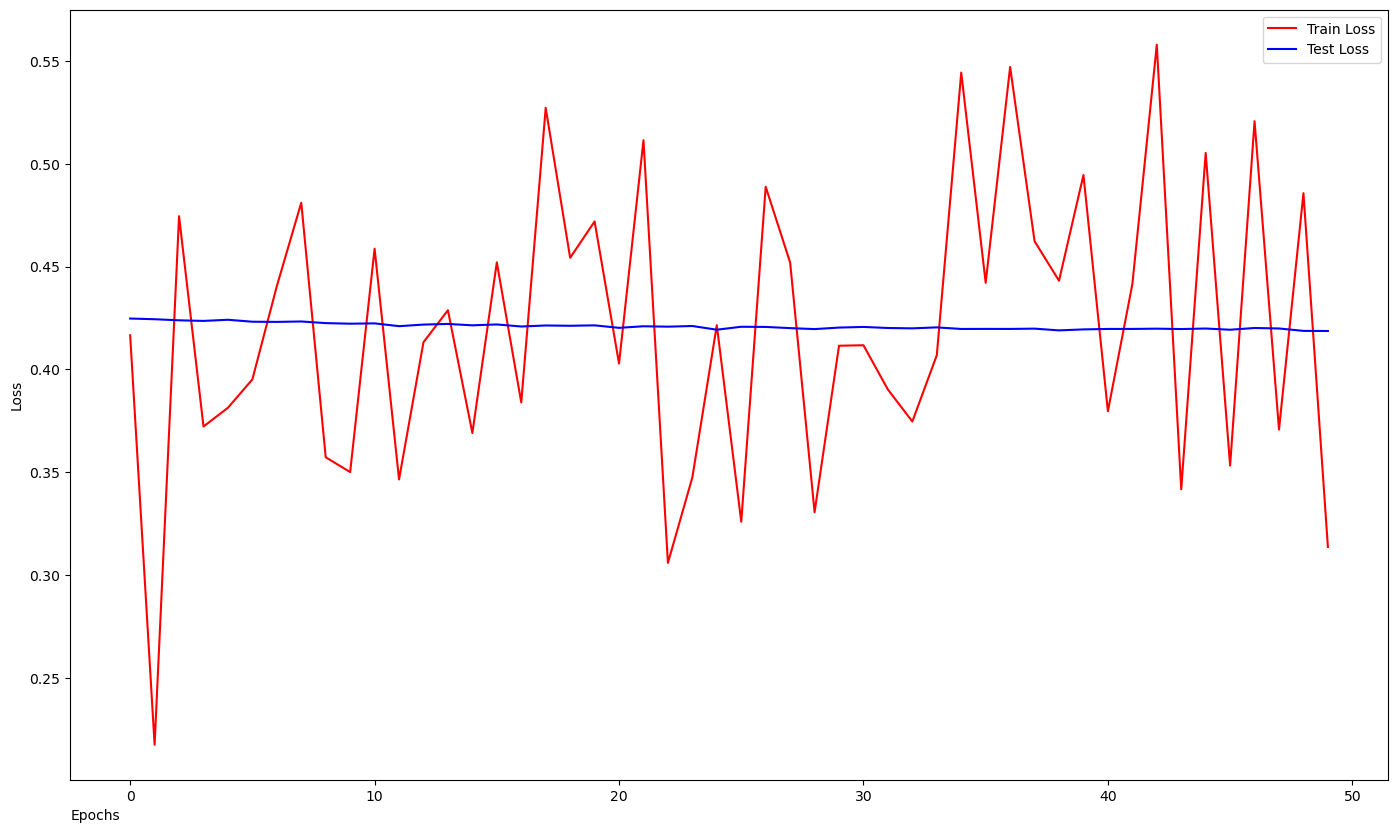

In [156]:
plt.figure(figsize=(17.0,10.0))
plt.xlabel("Epochs",loc='left')
plt.ylabel("Loss")
plt.plot(epoch_c, training_loss, c="red",label="Train Loss")
plt.plot(epoch_c, testing_loss, c="blue",label = "Test Loss")
plt.legend()
plt.plot()

[]

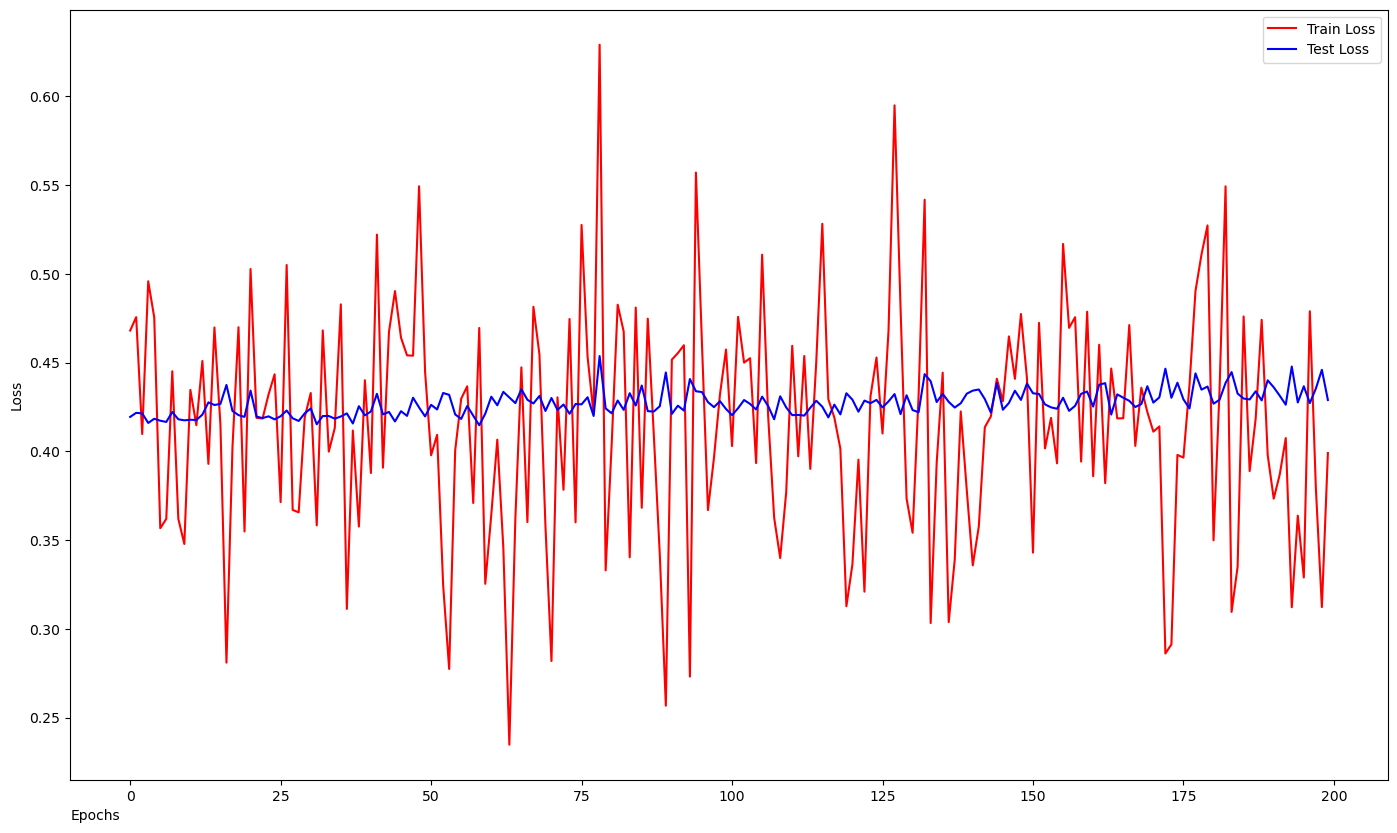

In [170]:
plt.figure(figsize=(17.0,10.0))
plt.xlabel("Epochs",loc='left')
plt.ylabel("Loss")
plt.plot(epoch_c, training_loss, c="red",label="Train Loss")
plt.plot(epoch_c, testing_loss, c="blue",label = "Test Loss")
plt.legend()
plt.plot()

### after changing optimizer from SGD -> Adam

[]

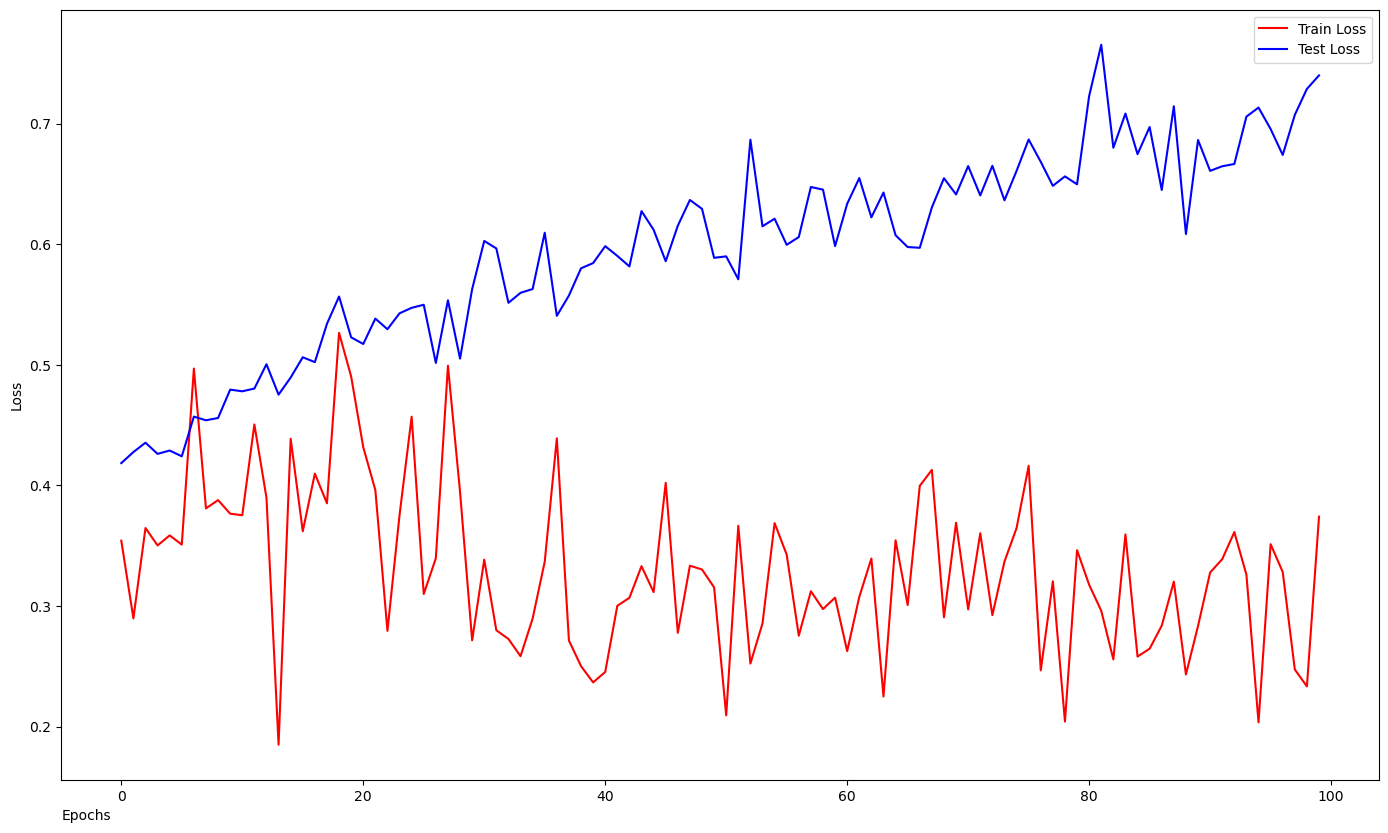

In [33]:
import matplotlib.pyplot as plt
plt.figure(figsize=(17.0,10.0))
plt.xlabel("Epochs",loc='left')
plt.ylabel("Loss")
plt.plot(epoch_c, training_loss, c="red",label="Train Loss")
plt.plot(epoch_c, testing_loss, c="blue",label = "Test Loss")
plt.legend()
plt.plot()

### After tweaking some loss logics 

[]

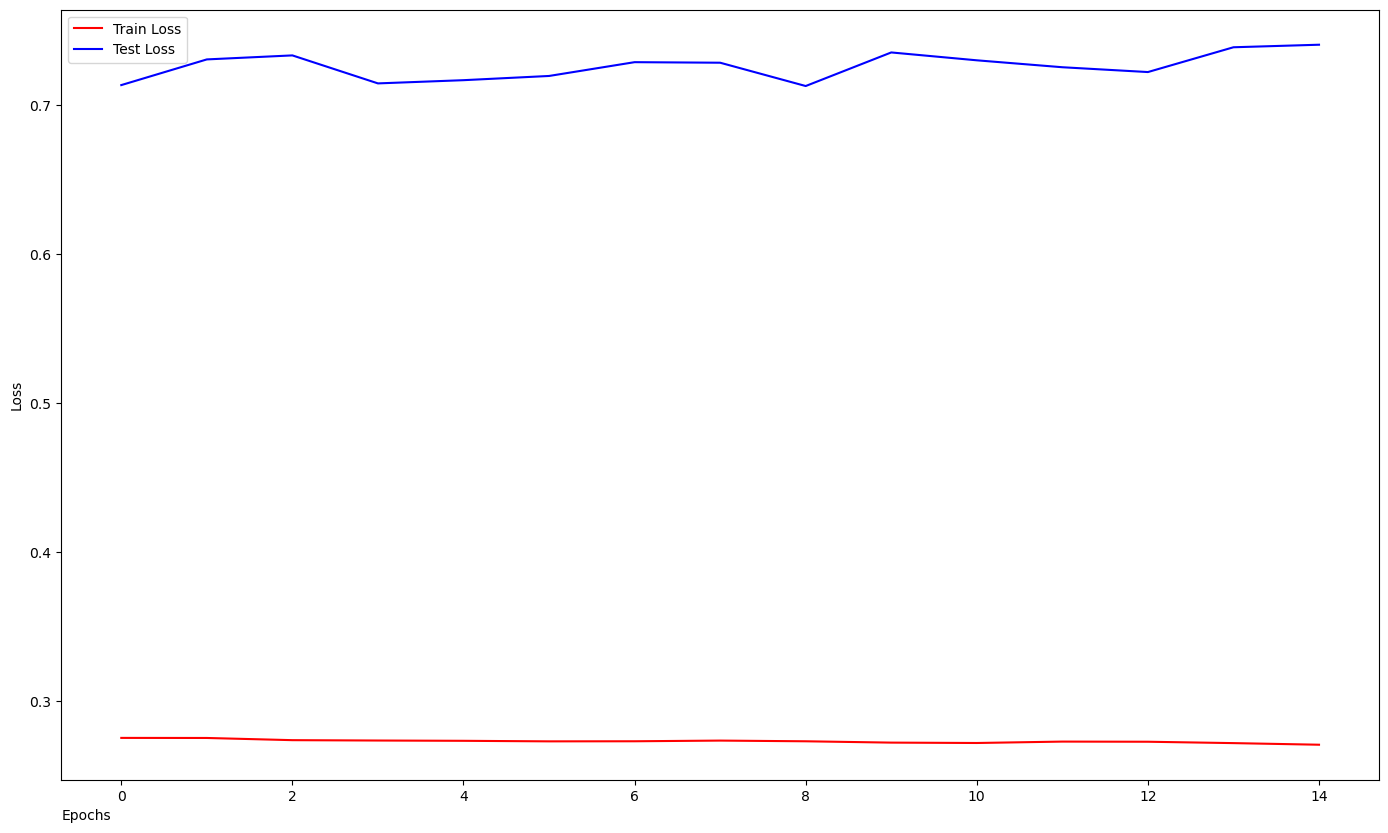

In [35]:
plt.figure(figsize=(17.0,10.0))
plt.xlabel("Epochs",loc='left')
plt.ylabel("Loss")
plt.plot(epoch_c, training_loss, c="red",label="Train Loss")
plt.plot(epoch_c, testing_loss, c="blue",label = "Test Loss")
plt.legend()
plt.plot()

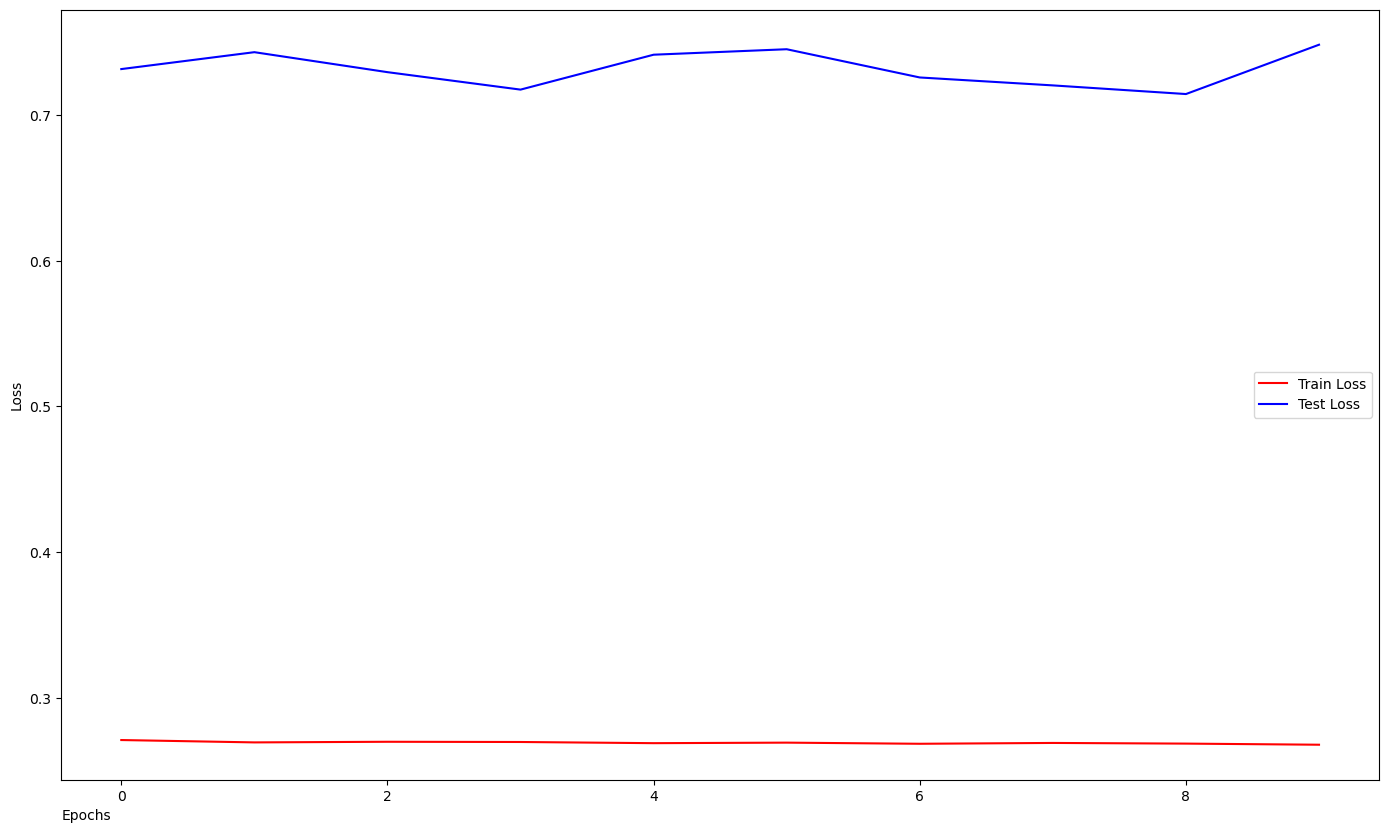

In [38]:
def plot(epoch_c, training_loss, testing_loss):
    plt.figure(figsize=(17.0,10.0))
    plt.xlabel("Epochs",loc='left')
    plt.ylabel("Loss")
    plt.plot(epoch_c, training_loss, c="red",label="Train Loss")
    plt.plot(epoch_c, testing_loss, c="blue",label = "Test Loss")
    plt.legend()
    plt.plot()

plot(epoch_c, training_loss, testing_loss)

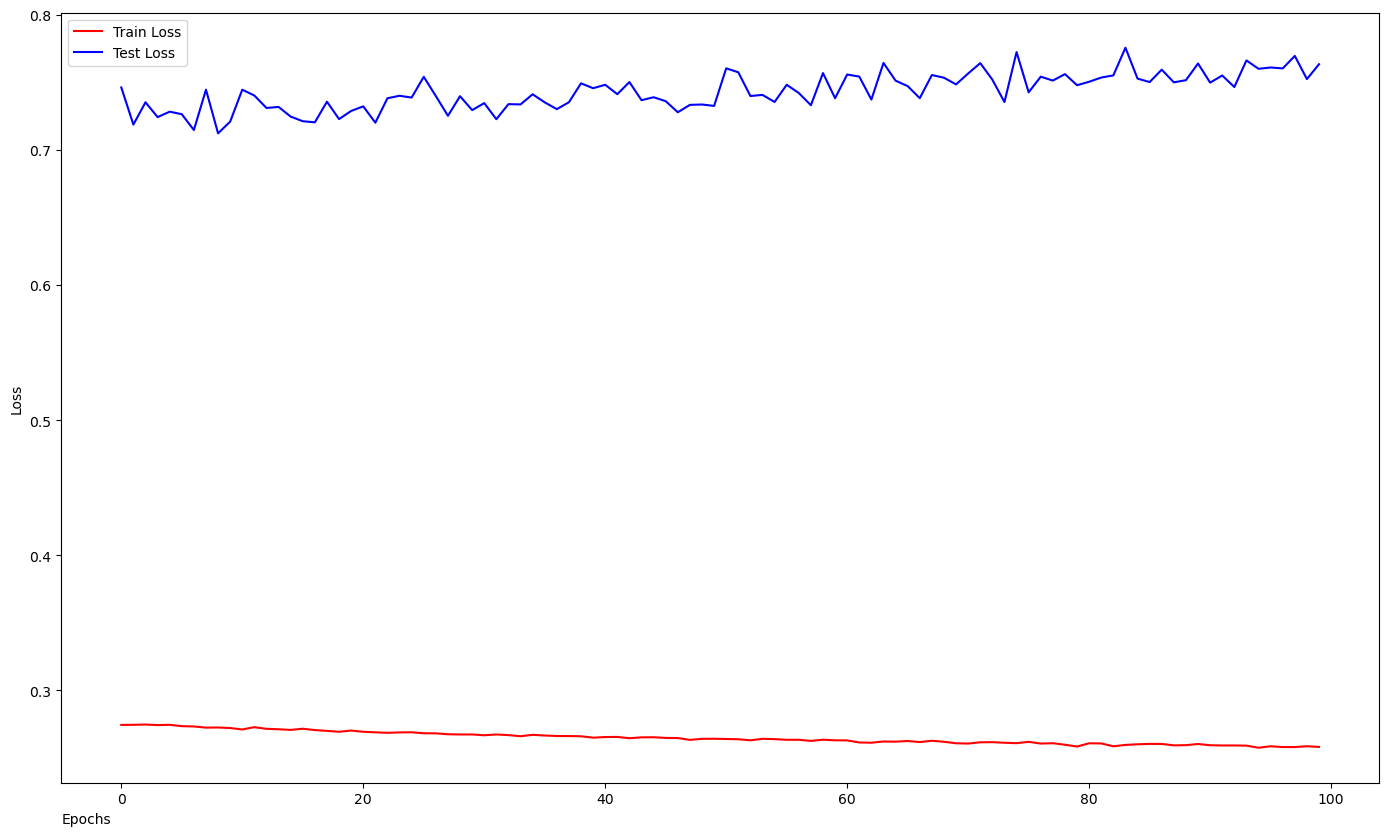

In [41]:
plot(epoch_c, training_loss, testing_loss)

### I think I should got to gradient boosted decision trees

### Lemme try my model

In [62]:
model.load_state_dict(torch.load("accident.pth"))
model.eval()

with torch.inference_mode():
    for X_batch, Y_batch in test_loader:

        sample = X_batch[2].unsqueeze(0)  
        output = model(sample)

        prediction = torch.argmax(output, dim=1)
        confidence = torch.softmax(output, dim=1).max().item()
        print("Predicted class :", prediction.item())
        print("Confidence      :", confidence)
        print("Actual class    :", Y_batch[2].item())
        break

Predicted class : 0
Confidence      : 0.7822847366333008
Actual class    : 2
